In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [4]:
import zipfile
import io

# Assuming 'archive (7).zip' is the correct key in 'uploaded'
zip_file_name = 'archive (7).zip'

if zip_file_name in uploaded:
    with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
        # Assuming 'Mall_Customers.csv' is inside the zip file
        with z.open('Mall_Customers.csv') as f:
            df = pd.read_csv(f)
    print(f"'{zip_file_name}' extracted and 'Mall_Customers.csv' loaded into DataFrame 'df'.")
else:
    print(f"Error: '{zip_file_name}' not found in uploaded files.")
    df = pd.DataFrame() # Initialize df as empty DataFrame to avoid further errors

df.head()

'archive (7).zip' extracted and 'Mall_Customers.csv' loaded into DataFrame 'df'.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
df = df.drop_duplicates()

print(df.shape)

(200, 5)


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = encoder.fit_transform(df[col])

In [12]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


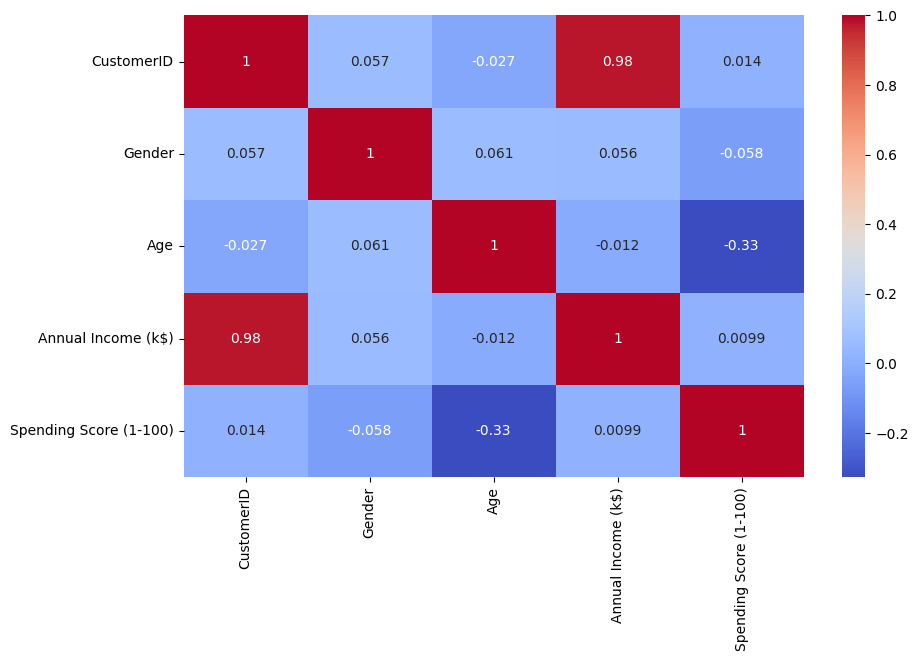

In [13]:
corr = df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

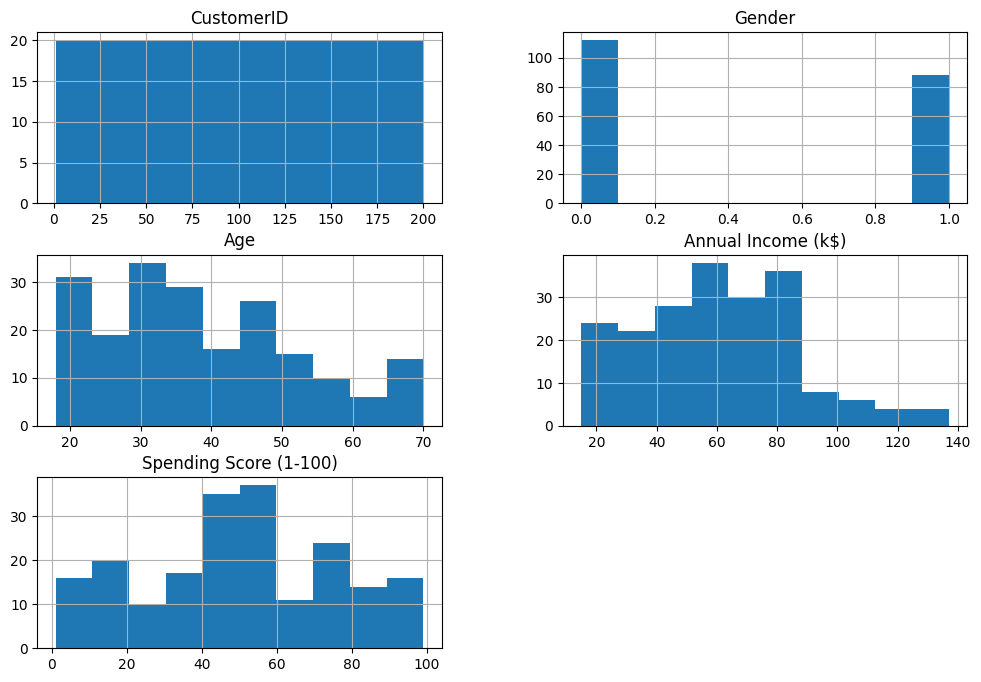

In [14]:
df.hist(figsize=(12,8))

plt.show()

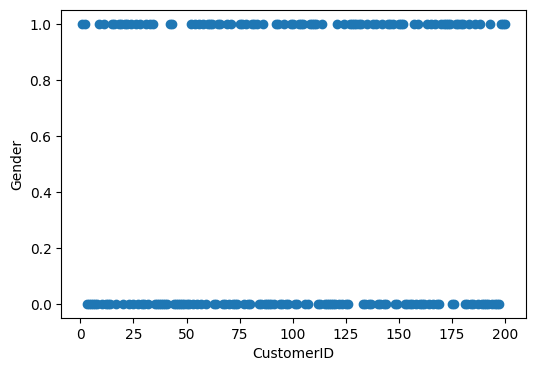

In [15]:
plt.figure(figsize=(6,4))

plt.scatter(df.iloc[:,0],
            df.iloc[:,1])

plt.xlabel(df.columns[0])

plt.ylabel(df.columns[1])

plt.show()

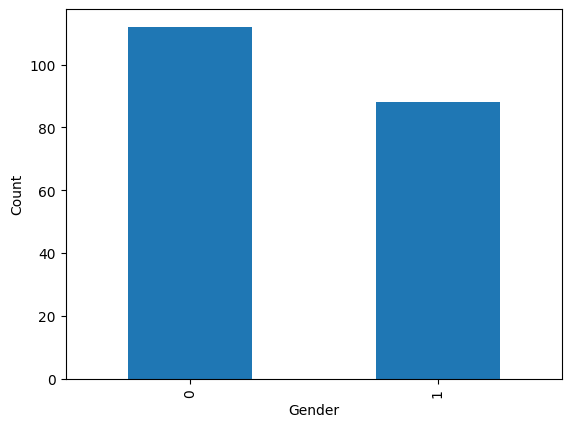

In [17]:
df["Gender"].value_counts().plot(kind="bar")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

In [19]:
X = df.drop("Gender", axis=1)

y = df["Gender"]

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

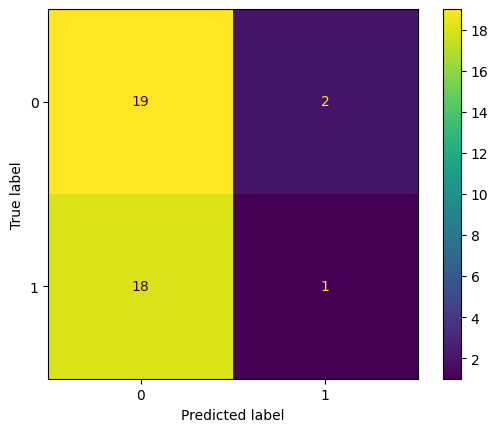

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [31]:
import joblib

model = joblib.load("best_model.pkl")

scaler = joblib.load("scaler.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pkl'